In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd


ONLINE_RATINGS_PATH: Path = Path(
    "../dataset/raw/metadata/online_ratings.xls"
)

online_ratings_df: pd.DataFrame = pd.read_excel(
    ONLINE_RATINGS_PATH
)

online_ratings_df.head()

,Online_id,Valence,Arousal,Dominance,Wheel_slice,Wheel_strength
0,1,4,4,3,11,3
1,1,8,3,3,3,4
2,1,5,1,1,3,2
3,1,5,3,5,3,1
4,1,7,1,7,7,1


In [2]:
num_records: int = online_ratings_df.shape[0]
num_columns: int = online_ratings_df.shape[1]

print(f"Number of records: {num_records:,}")
print(f"Number of columns: {num_columns:,}")

Number of records: 1,778
Number of columns: 6


In [3]:
online_ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1778 entries, 0 to 1777
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Online_id       1778 non-null   int64
 1   Valence         1778 non-null   int64
 2   Arousal         1778 non-null   int64
 3   Dominance       1778 non-null   int64
 4   Wheel_slice     1778 non-null   int64
 5   Wheel_strength  1778 non-null   int64
dtypes: int64(6)
memory usage: 83.5 KB


In [4]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [5]:
ONLINE_RATINGS_PATH: Path = Path(
    "../dataset/raw/metadata/online_ratings.xls"
)

online_ratings_df: pd.DataFrame = pd.read_excel(
    ONLINE_RATINGS_PATH
)

online_ratings_df.head()

,Online_id,Valence,Arousal,Dominance,Wheel_slice,Wheel_strength
0,1,4,4,3,11,3
1,1,8,3,3,3,4
2,1,5,1,1,3,2
3,1,5,3,5,3,1
4,1,7,1,7,7,1


In [6]:
online_ratings_df.describe()

,Online_id,Valence,Arousal,Dominance,Wheel_slice,Wheel_strength
count,1778.000000,1778.000000,1778.000000,1778.00000,1778.000000,1778.000000
mean,60.931946,5.320022,4.794713,5.02081,6.925197,2.323397
std,34.424857,2.094679,2.274627,2.09781,4.809427,1.244695
min,1.000000,1.000000,1.000000,1.00000,0.000000,0.000000
25%,31.000000,4.000000,3.000000,4.00000,3.000000,1.000000
50%,61.000000,5.000000,5.000000,5.00000,6.500000,2.000000
75%,91.000000,7.000000,7.000000,6.00000,9.000000,3.000000
max,120.000000,9.000000,9.000000,9.00000,16.000000,4.000000


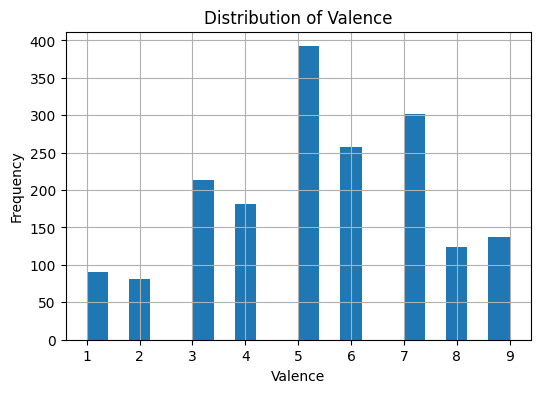

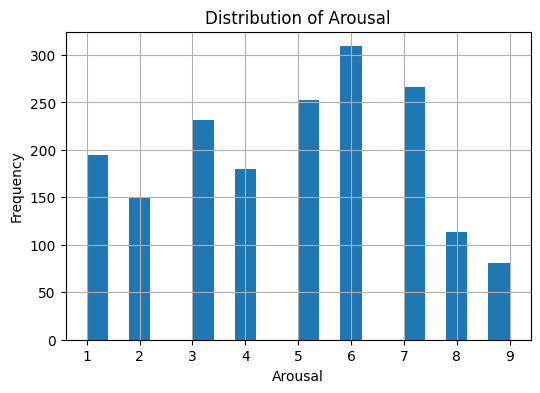

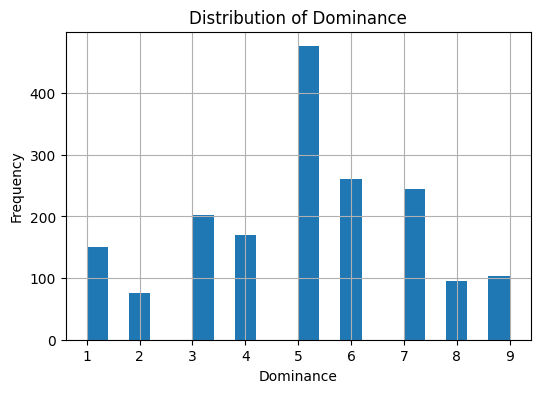

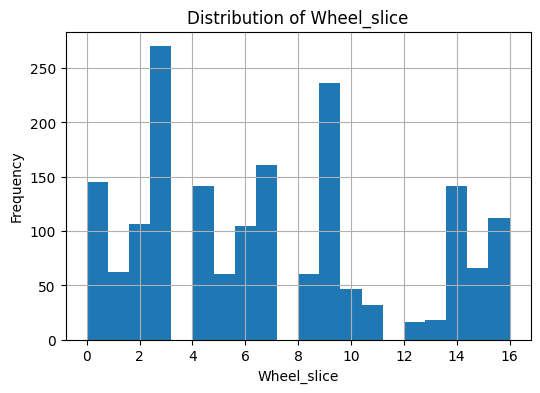

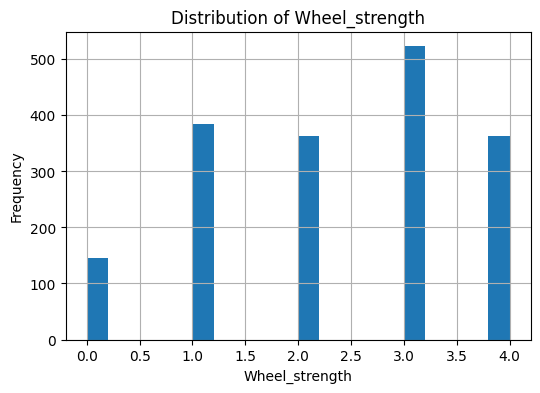

In [7]:
numeric_columns: list[str] = [
    "Valence",
    "Arousal",
    "Dominance",
    "Wheel_slice",
    "Wheel_strength",
]

for column in numeric_columns:

    plt.figure(figsize=(6, 4))

    plt.hist(
        online_ratings_df[column],
        bins=20,
    )

    plt.title(f"Distribution of {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()

In [8]:
statistics_df: pd.DataFrame = pd.DataFrame(
    columns=[
        "Mean",
        "Median",
        "Mode",
        "Std",
        "Min",
        "Max",
    ]
)

for column in numeric_columns:

    statistics_df.loc[column] = [
        online_ratings_df[column].mean(),
        online_ratings_df[column].median(),
        online_ratings_df[column].mode()[0],
        online_ratings_df[column].std(),
        online_ratings_df[column].min(),
        online_ratings_df[column].max(),
    ]

statistics_df

,Mean,Median,Mode,Std,Min,Max
Valence,5.320022,5.0,5.0,2.094679,1.0,9.0
Arousal,4.794713,5.0,6.0,2.274627,1.0,9.0
Dominance,5.020810,5.0,5.0,2.097810,1.0,9.0
Wheel_slice,6.925197,6.5,3.0,4.809427,0.0,16.0
Wheel_strength,2.323397,2.0,3.0,1.244695,0.0,4.0


In [9]:
covariance_matrix: pd.DataFrame = (
    online_ratings_df[numeric_columns]
    .cov()
)

covariance_matrix

,Valence,Arousal,Dominance,Wheel_slice,Wheel_strength
Valence,4.387680,1.684754,1.875160,-4.962542,0.487894
Arousal,1.684754,5.173928,2.066739,-2.040688,0.603286
Dominance,1.875160,2.066739,4.400805,-2.376608,0.195292
Wheel_slice,-4.962542,-2.040688,-2.376608,23.130586,1.088358
Wheel_strength,0.487894,0.603286,0.195292,1.088358,1.549267


In [10]:
correlation_matrix: pd.DataFrame = (
    online_ratings_df[numeric_columns]
    .corr(method="pearson")
)

correlation_matrix

,Valence,Arousal,Dominance,Wheel_slice,Wheel_strength
Valence,1.000000,0.353597,0.426732,-0.492599,0.187131
Arousal,0.353597,1.000000,0.433121,-0.186541,0.213084
Dominance,0.426732,0.433121,1.000000,-0.235558,0.074792
Wheel_slice,-0.492599,-0.186541,-0.235558,1.000000,0.181809
Wheel_strength,0.187131,0.213084,0.074792,0.181809,1.000000


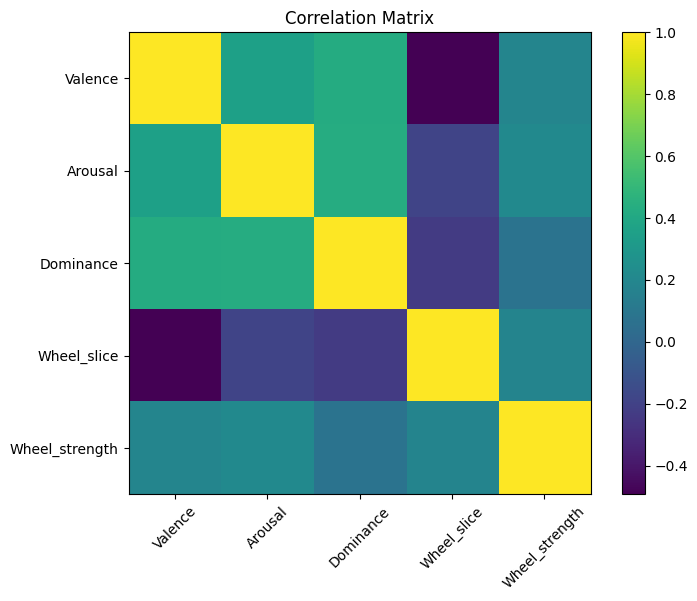

In [11]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
)

plt.title("Correlation Matrix")

plt.show()

In [15]:
online_ratings_df[["Valence", "Arousal", "Dominance"]].describe()

,Valence,Arousal,Dominance
count,1778.000000,1778.000000,1778.00000
mean,5.320022,4.794713,5.02081
std,2.094679,2.274627,2.09781
min,1.000000,1.000000,1.00000
25%,4.000000,3.000000,4.00000
50%,5.000000,5.000000,5.00000
75%,7.000000,7.000000,6.00000
max,9.000000,9.000000,9.00000


In [17]:
correlation_matrix: pd.DataFrame = (
    online_ratings_df[
        ["Valence", "Arousal", "Dominance", "Wheel_slice", "Wheel_strength"]
    ]
    .corr(method="pearson")
)

correlation_matrix

,Valence,Arousal,Dominance,Wheel_slice,Wheel_strength
Valence,1.000000,0.353597,0.426732,-0.492599,0.187131
Arousal,0.353597,1.000000,0.433121,-0.186541,0.213084
Dominance,0.426732,0.433121,1.000000,-0.235558,0.074792
Wheel_slice,-0.492599,-0.186541,-0.235558,1.000000,0.181809
Wheel_strength,0.187131,0.213084,0.074792,0.181809,1.000000


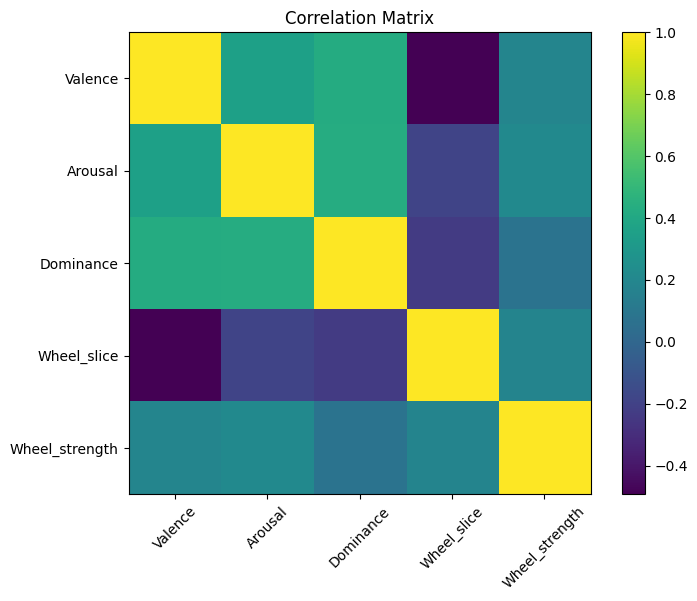

In [18]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
)

plt.title("Correlation Matrix")

plt.show()